In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

from utils_jax import *
dq.set_device('cpu')
import optax

# Get some initial params

In [15]:
EJ = 4
EC = 4/5.9
EL = 4/29.2

n_lvls_transmon  = 4
n_lvls_fluxonium = 20

qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": EJ, "Ec": EC, "El": EL, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )

In [16]:
def detuned_rabi_period(amp_with_2pi, element, detunning):
    # element: obtained from scqubit operator
    # detunning: obtained from scqubit
    return 2*jnp.pi / jnp.sqrt(
        (amp_with_2pi*element)**2
        + (2*jnp.pi*detunning)**2
    )

In [17]:
def objective(params):    
    one_period_mult = 0.5
    zero_period_mult = 1
    two_period_mult = 1

    Ej_t, g_tf, amp_with_2pi = params
    

    qst = MyTransmon.create(
        N = n_lvls_transmon,
        params = {"Ej": Ej_t, "Ec": 0.2,"ng":0.0},
        N_max_charge=10
        )

    devices = [qsf, qst]
    f_indx = 0
    t_indx = 1
    Ns = [device.N for device in devices]
    fn = qs.promote(qsf.ops["n"], f_indx, Ns)
    tn = qs.promote(qst.ops['n'], t_indx, Ns)

    system = qs.System.create(devices, couplings=[
        g_tf *  fn @ tn
        ])
    system.params["g_tf"] = g_tf
    system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
    system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
    driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)

    def get_dressed_idx(ql,tl):
        return find_closest_dressed_index(ql*qst.N+tl, product_indices_sorted_by_eval)
    zero = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]
    one = system_evals_in_product_indices[1,1] - system_evals_in_product_indices[1,0]
    two = system_evals_in_product_indices[2,1] - system_evals_in_product_indices[2,0]
    zero_period = detuned_rabi_period(amp_with_2pi, jnp.abs(driven_op[get_dressed_idx(0,0),get_dressed_idx(0,1)]),one -zero)
    one_period = detuned_rabi_period(amp_with_2pi, jnp.abs(driven_op[get_dressed_idx(1,0),get_dressed_idx(1,1)]),one -one)
    two_period = detuned_rabi_period(amp_with_2pi, jnp.abs(driven_op[get_dressed_idx(2,0),get_dressed_idx(2,1)]),one -two)

    return jnp.abs(one_period*one_period_mult - zero_period*zero_period_mult)/one_period + \
        jnp.abs(one_period*one_period_mult - two_period*two_period_mult)/one_period

func = jax.value_and_grad(objective)

# Analyze the parameters I found from param sweep with g=0.2

In [123]:
params = jnp.array( [35.40918,  0.2,  0.05909091, ]) #     Ej_t, g_tf, amp_with_2pi = params

optimizer = optax.nadam(learning_rate=jnp.array([1e-2,1e-2,1e-2])) 
opt_state = optimizer.init(params)

num_steps = 1000
for step in range(num_steps):
    val, grads = func(params)
    # clear_output()
    print(f"iter: {step}, val={val:.4f} grads: {grads}, params: {params}")
    if val < 1e-4:
        break
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

print(f'Optimized params: {params}')

iter: 0, val=0.0274 grads: [3.80413049 7.98515988 8.22463391], params: [35.40918     0.2         0.05909091]
iter: 1, val=0.0643 grads: [ -3.74479588 -13.98981965  12.75800173], params: [35.39444316  0.18526316  0.04435407]
iter: 2, val=0.2594 grads: [  3.2739316   12.31676391 -17.43974178], params: [3.53999473e+01 1.93709992e-01 3.18616339e-02]
iter: 3, val=0.0927 grads: [  3.61039667  13.6749098  -16.13159385], params: [35.39444485  0.18844383  0.03654347]
iter: 4, val=0.1120 grads: [ -3.71386474 -14.17224079  13.51255557], params: [35.38771072  0.18173362  0.04228621]
iter: 5, val=0.0421 grads: [ -3.71386012 -14.17306063  14.67116869], params: [35.38917378  0.18399192  0.03998631]
iter: 6, val=0.0852 grads: [  3.61037458  13.75450833 -16.46433531], params: [35.39227172  0.1878492   0.03601881]
iter: 7, val=0.0167 grads: [-0.07603808 -0.10992385 -0.10357792], params: [35.38956909  0.18539614  0.03859556]
iter: 8, val=0.0168 grads: [-0.07444397 -0.10252044 -0.11430045], params: [35.38

KeyboardInterrupt: 

# Let's check the short period one

In [6]:
transmon_EJ,g,amp =  [35.38952556 , 0.18709965,  0.0412777 ]

fluxonium = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=transmon_EJ,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = g,
    )

e_ops = []
for ql in range(n_lvls_fluxonium):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))


amp_with_2pi = amp
t_tot = 100
tlist = np.linspace(0,t_tot,int(t_tot))


results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]],
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': 4,
                    't_square': 1000
                  },
                )],
        c_ops = None,
        e_ops = e_ops
    )


 /home/kai/miniconda3/envs/test/lib/python3.10/site-packages/loky/backend/fork_exec.py: 38An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


 Total run time:  39.27s*] Elapsed 39.27s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00
 [*********98%***********] Elapsed 39.41s / Remaining 00:00:00:00

Processing states with pad_back_custom: 100%|██████████| 100/100 [00:00<00:00, 7199.41it/s]


 Total run time:  39.50s*] Elapsed 39.50s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 100/100 [00:00<00:00, 4647.58it/s]


 Total run time:  39.88s*] Elapsed 39.88s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 100/100 [00:00<00:00, 6756.62it/s]


(65.0, 70.0)

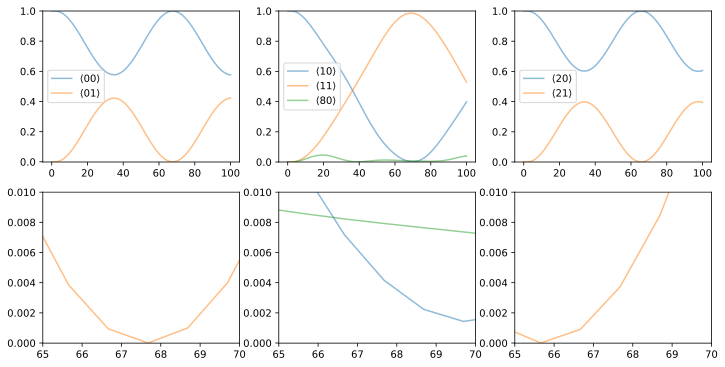

In [21]:


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1)],
                        [(1,0),(1,1),(8,0)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            # if (ql,tl) not in [(0,0), (1,1),(2,0)]:
            axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
            # else:
            #     axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)
axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)
axes[1,0].set_ylim(-1e-5,1e-2)
axes[1,1].set_ylim(-1e-5,1e-2)
axes[1,2].set_ylim(-1e-5,1e-2)

axes[1,0].set_xlim(65,70)
axes[1,1].set_xlim(65,70)
axes[1,2].set_xlim(65,70)

# Let's check the long one

In [22]:
params = jnp.array( [49.55102,  0.2,  0.006742424 ]) #     Ej_t, g_tf, amp_with_2pi = params

optimizer = optax.nadam(learning_rate=jnp.array([1e-2,1e-2,2e-3])) 
opt_state = optimizer.init(params)

num_steps = 1000
for step in range(num_steps):
    val, grads = func(params)
    # clear_output()
    print(f"iter: {step}, val={val:.4f} grads: {grads}, params: {params}")
    if val < 1e-4:
        break
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

print(f'Optimized params: {params}')

iter: 0, val=0.0044 grads: [-0.93565776 -3.39494641 -0.69477193], params: [4.955102e+01 2.000000e-01 6.742424e-03]
iter: 1, val=0.2117 grads: [ 0.38612889 -5.07898832 80.79679346], params: [4.95657568e+01 2.14736842e-01 9.68979238e-03]
iter: 2, val=0.0928 grads: [0.76312136 2.77930991 5.14469197], params: [4.95650330e+01 2.27177420e-01 7.26978069e-03]
iter: 3, val=0.1715 grads: [  -0.34013894    4.05769374 -108.88369676], params: [4.95599235e+01 2.27598090e-01 6.32301864e-03]
iter: 4, val=0.0839 grads: [0.78752746 2.90431177 4.0943911 ], params: [4.95615070e+01 2.24605919e-01 7.51063832e-03]
iter: 5, val=0.0705 grads: [0.81570408 3.03510852 3.14607377], params: [4.95565444e+01 2.21231637e-01 7.67566769e-03]
iter: 6, val=0.0519 grads: [0.85135673 3.18307559 2.2378804 ], params: [4.95504162e+01 2.16776001e-01 7.80714421e-03]
iter: 7, val=0.0608 grads: [ 0.44896439 -4.92013237 97.92174816], params: [4.95434067e+01 2.11418328e-01 7.91530571e-03]
iter: 8, val=0.0486 grads: [  -0.4394752    

In [25]:
transmon_EJ,g,amp =  [4.94486042e+01, 2.27345094e-01, 8.49354527e-03]

fluxonium = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=transmon_EJ,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = g,
    )

e_ops = []
for ql in range(n_lvls_fluxonium):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))


amp_with_2pi = amp
t_tot = 350
tlist = np.linspace(0,t_tot,int(t_tot))


results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]],
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': 4,
                    't_square': 1000
                  },
                )],
        c_ops = None,
        e_ops = e_ops
    )


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


 Total run time: 184.18s*] Elapsed 184.18s / Remaining 00:00:00:00
 [*********98%***********] Elapsed 184.36s / Remaining 00:00:00:03

Processing states with pad_back_custom: 100%|██████████| 350/350 [00:00<00:00, 5866.14it/s]


 Total run time: 187.92s*] Elapsed 187.92s / Remaining 00:00:00:00
 [*********99%***********] Elapsed 188.05s / Remaining 00:00:00:01

Processing states with pad_back_custom: 100%|██████████| 350/350 [00:00<00:00, 6050.07it/s]


 Total run time: 189.94s*] Elapsed 189.94s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 350/350 [00:00<00:00, 6255.70it/s]


(210.0, 240.0)

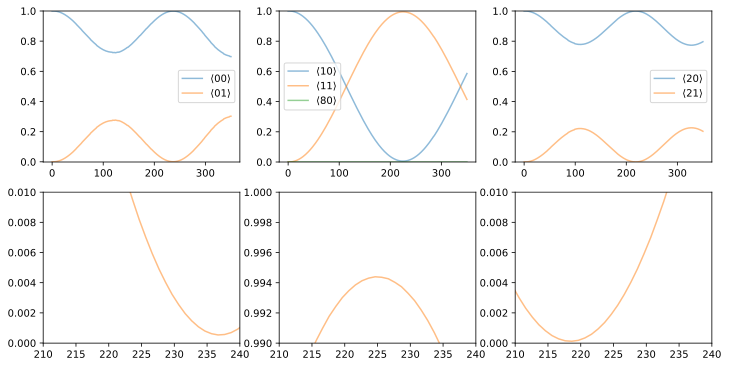

In [32]:


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1)],
                        [(1,0),(1,1),(8,0)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            # if (ql,tl) not in [(0,0), (1,1),(2,0)]:
            axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
            # else:
            #     axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)
axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)
axes[1,0].set_ylim(-1e-5,1e-2)
axes[1,1].set_ylim(1-1e-2,1)
axes[1,2].set_ylim(-1e-5,1e-2)

xa = 210
xb = 240
axes[1,0].set_xlim(xa,xb)
axes[1,1].set_xlim(xa,xb)
axes[1,2].set_xlim(xa,xb)

# Checking params for g=0.1

In [51]:
params = jnp.array( [35.6161, 0.1,0.02718593 ]) #     Ej_t, g_tf, amp_with_2pi = params

optimizer = optax.nadam(learning_rate=jnp.array([3e-4,3e-4,3e-4])) 
opt_state = optimizer.init(params)

num_steps = 1000
for step in range(num_steps):
    val, grads = func(params)
    # clear_output()
    print(f"iter: {step}, val={val:.4f} grads: {grads}, params: {params}")
    if val < 1e-4:
        break
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

print(f'Optimized params: {params}')

iter: 0, val=0.0070 grads: [ 0.05302022  0.1744077  -0.12031546], params: [3.561610e+01 1.000000e-01 2.718593e-02]
iter: 1, val=0.0082 grads: [ 7.70639824  5.2077629  18.24355314], params: [3.56156579e+01 9.95578948e-02 2.76280352e-02]
iter: 2, val=0.0068 grads: [ 0.05267546  0.17196113 -0.11526654], params: [3.56152929e+01 9.91897498e-02 2.72647739e-02]
iter: 3, val=0.0072 grads: [ -7.74606062  -5.24104158 -18.6823842 ], params: [3.56151675e+01 9.90530037e-02 2.71451891e-02]
iter: 4, val=0.0068 grads: [ 0.0525707   0.17188894 -0.11551391], params: [3.56153083e+01 9.91898768e-02 2.72906609e-02]
iter: 5, val=0.0068 grads: [ 0.0524933   0.17184607 -0.11572177], params: [3.56153219e+01 9.91946922e-02 2.73101475e-02]
iter: 6, val=0.0068 grads: [ 0.05242116  0.17179856 -0.11589726], params: [3.56153334e+01 9.91957369e-02 2.73280218e-02]


KeyboardInterrupt: 

In [52]:
transmon_EJ,g,amp =  [3.56153334e+01, 9.91957369e-02, 2.73280218e-02]

fluxonium = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=transmon_EJ,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = g,
    )

e_ops = []
for ql in range(n_lvls_fluxonium):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))


amp_with_2pi = amp
t_tot = 150
tlist = np.linspace(0,t_tot,int(t_tot))


results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]],
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': 4,
                    't_square': 1000
                  },
                )],
        c_ops = None,
        e_ops = e_ops
    )


 /home/kai/miniconda3/envs/test/lib/python3.10/site-packages/loky/backend/fork_exec.py: 38An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


 Total run time:  60.05s*] Elapsed 60.05s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 150/150 [00:00<00:00, 7430.82it/s]


 Total run time:  60.62s*] Elapsed 60.62s / Remaining 00:00:00:00
 Total run time:  60.73s*] Elapsed 60.72s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 150/150 [00:00<00:00, 6878.76it/s]


(100.0, 115.0)

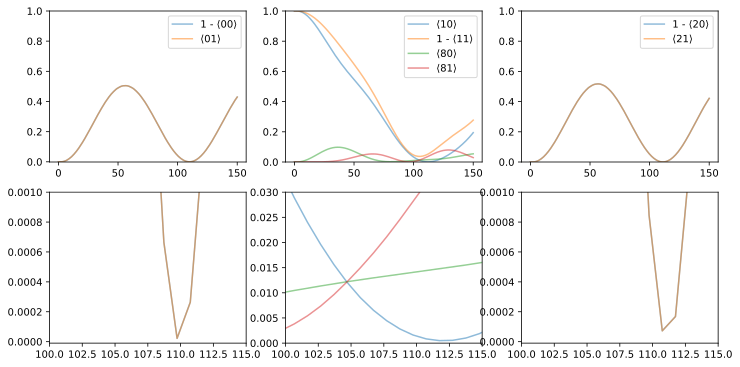

In [55]:


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1)],
                        [(1,0),(1,1),(8,0),(8,1)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,0), (1,1),(2,0)]:
                axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
            else:
                axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)
axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)
axes[1,0].set_ylim(-1e-5,1e-3)
axes[1,1].set_ylim(-1e-5,3e-2)
axes[1,2].set_ylim(-1e-5,1e-3)

xa = 100
xb = 115
axes[1,0].set_xlim(xa,xb)
axes[1,1].set_xlim(xa,xb)
axes[1,2].set_xlim(xa,xb)